# Notebook 2: Feature Engineering & Pemodelan
## Ekstraksi Fitur, Penanganan Data Timpang & Pemodelan Klasifikasi Sentimen

## 1. Pendahuluan & Hubungan Antar-Notebook
Notebook ini merupakan kelanjutan langsung (**Tahap 2**) dari siklus pengembangan proyek *Multi-class Sentiment Analysis*. Pada Notebook 1, kita telah menyelesaikan fase *preprocessing* massal (pembersihan teks, audit duplikat, dan penormalan kosakata). 

Seluruh teks ulasan kini telah bersih, rapi, dan tersimpan dalam file fisik `.tsv` di direktori `../data/processed/`. Di Notebook 2 ini, kita akan mentransformasikan data bersih tersebut menjadi representasi numerik (vektor), menangani isu ketidakseimbangan kelas (*class imbalance*), serta melatih berbagai algoritma *Machine Learning* untuk mengklasifikasikan sentimen secara objektif guna menemukan model terbaik untuk fase produksi.

## 2. Tujuan Eksperimen
1. **Ekstraksi Fitur:** Mengubah teks bersih menjadi matriks pembobotan menggunakan *Term Frequency - Inverse Document Frequency* (TF-IDF).
2. **Penanganan Data Timpang:** Menggunakan algoritma SMOTE murni pada data latih agar model tidak bias terhadap kelas mayoritas.
3. **Kompetisi Multi-Model & Optimasi:** Membandingkan performa *Logistic Regression* (Baseline), *Random Forest*, dan *K-Nearest Neighbors* (KNN), serta melakukan tuning parameter terbaik menggunakan *GridSearchCV*.
4. **Evaluasi:** Mengukur performa menggunakan *Macro F1-Score* untuk memastikan keadilan prediksi di semua kelas sentimen.

---

## 3. Alur Langkah Pengerjaan
Rangkaian eksperimen ini disusun secara linear ke dalam 6 tahapan:
* **Langkah 1:** *Data Loading* — Memuat dataset bersih (`train_clean.tsv`, dsb).
* **Langkah 2:** *Feature Extraction* — Transformasi TF-IDF (Fit hanya pada *Train*).
* **Langkah 3:** *Handling Class Imbalance* — Penyeimbangan data menggunakan SMOTE pada data training.
* **Langkah 4:** *Baseline Modeling & Tuning* — Pembangunan dan optimasi model *Logistic Regression* melalui *GridSearchCV*.
* **Langkah 5:** *Multi-Model Competition* — Pelatihan model *Random Forest* & *KNN* sebagai pembanding.
* **Langkah 6:** *Model Export* — Penyimpanan model terbaik (*Logistic Regression* juara) dan objek vectorizer ke format `.pkl` untuk deployment di Notebook 3.

## LANGKAH 1: MEMUAT DATASET HASIL PREPROCESSING (PROCESSED DATA LOADING)

Pada langkah ini, kita memuat kembali tiga subset file data fisik `.tsv` (*Train*, *Validation*, dan *Test*) yang telah dibersihkan secara massal pada tahapan akhir di Notebook 1. 

Kita melakukan verifikasi dimensi baris dan kolom secara ketat untuk memastikan bahwa seluruh data operasional yang akan dialirkan ke tahap pemodelan tetap konsisten, serta memastikan kolom fitur baru (`text_clean`) telah termuat sempurna bersama kolom mentah asli.

In [1]:
# ==============================================================================
# LANGKAH 1 NB2: LOAD PROCESSED DATASET (.TSV BERSIH)
# ==============================================================================
import os
import pandas as pd

# 1. Menentukan direktori folder data processed
processed_dir = "../data/processed/"

# 2. Memuat dataset bersih menggunakan pembatas tabulator (\t)
df_train = pd.read_csv(os.path.join(processed_dir, "train_clean.tsv"), sep='\t')
df_valid = pd.read_csv(os.path.join(processed_dir, "valid_clean.tsv"), sep='\t')
df_test = pd.read_csv(os.path.join(processed_dir, "test_clean.tsv"), sep='\t')

# 3. Verifikasi dimensi
print("=== VERIFIKASI DIMENSI DATA BERSIH (OPERASIONAL) ===")
print(f"Data Train Bersih      : {df_train.shape[0]} baris, {df_train.shape[1]} kolom")
print(f"Data Validation Bersih : {df_valid.shape[0]} baris, {df_valid.shape[1]} kolom")
print(f"Data Test Bersih       : {df_test.shape[0]} baris, {df_test.shape[1]} kolom\n")

# 4. Cek struktur kolom
print("=== MEMERIKSA KETERSEDIAAN KOLOM BERSIH ===")
print("Kolom yang tersedia:", df_train.columns.tolist())
print(df_train.head(3))

=== VERIFIKASI DIMENSI DATA BERSIH (OPERASIONAL) ===
Data Train Bersih      : 10933 baris, 3 kolom
Data Validation Bersih : 1260 baris, 3 kolom
Data Test Bersih       : 500 baris, 3 kolom

=== MEMERIKSA KETERSEDIAAN KOLOM BERSIH ===
Kolom yang tersedia: ['text', 'sentiment', 'text_clean']
                                                text sentiment  \
0  warung ini dimiliki oleh pengusaha pabrik tahu...  positive   
1  mohon ulama lurus dan k212 mmbri hujjah partai...   neutral   
2  lokasi strategis di jalan sumatera bandung . t...  positive   

                                          text_clean  
0  warung ini dimiliki oleh pengusaha pabrik tahu...  
1  mohon ulama lurus dan k mmbri hujjah partai ap...  
2  lokasi strategis di jalan sumatera bandung tem...  


### INSIGHT & ANALISIS HASIL TAHAPAN 1: INTEGRITAS PROCESSED DATA

Berdasarkan hasil pemuatan dan verifikasi data pada sel di atas, diperoleh tiga poin konfirmasi penting yang menjamin kesiapan data sebelum masuk ke tahap rekayasa fitur:

1. **Stabilitas dan Konsistensi Volume Data Mutlak**
   Jumlah baris pada setiap subset data terkunci secara konsisten: **10.933** baris data *Train*, **1.260** baris data *Validation*, dan **500** baris data *Test*. Angka ini sama persis dengan matriks hasil akhir audit pada Notebook 1, membuktikan proses ekspor-impor data via file fisik `.tsv` berjalan stabil tanpa ada risiko data hilang (*data loss*) atau rusak akibat isu pembatas karakter (*parsing error*).

2. **Kesiapan Fitur Operasional (Struktur 3 Kolom)**
   Pengecekan struktur kolom menunjukkan format data kini telah diperkaya menjadi **3 kolom operasional** (`text`, `sentiment`, dan `text_clean`). Kolom `text_clean` hasil normalisasi bahasa gaul dan pembersihan *noise* regex inilah yang akan diisolasi dan dialirkan sebagai input tunggal menuju proses ekstraksi fitur berbasis matriks pembobotan kata pada langkah berikutnya.

3. **Pemberlakuan Isolasi Jalur untuk Mitigasi *Data Leakage***
   Kita sengaja mempertahankan pemisahan tiga berkas ini semenjak dari awal pembacaan data. Hal ini merupakan langkah preventif yang krusial dalam *Data Science* untuk mencegah **Kebocoran Data (*Data Leakage*)**. Implementasi praktisnya: objek pembobot teks (*Vectorizer*) hanya akan mempelajari pola distribusi kata (*fit*) menggunakan data dari `df_train`, sedangkan `df_valid` dan `df_test` murni hanya akan dikenai transformasi (*transform*) tanpa boleh mempengaruhi isi kamus model.

## LANGKAH 2: EKSTRAKSI FITUR TEKS MENGGUNAKAN TF-IDF

Langkah ini bertujuan mengubah fitur `text_clean` yang semula berupa untaian string menjadi representasi angka dalam bentuk matriks pembobotan statistik (**Sparse Matrix**) menggunakan objek `TfidfVectorizer`. 

Metode *Term Frequency - Inverse Document Frequency* (TF-IDF) ini bekerja dengan memberikan bobot lebih tinggi pada kata-kata yang informatif/unik dan mendiskon nilai kata-kata umum yang terlalu sering muncul di seluruh dokumen (*stop words*). Dengan demikian, model *Machine Learning* dapat berfokus penuh pada pola ekspresi sentimen yang spesifik.

In [2]:
# ==============================================================================
# LANGKAH 2: EKSTRAKSI FITUR DENGAN TF-IDF (TfidfVectorizer)
# ==============================================================================
from sklearn.feature_extraction.text import TfidfVectorizer

def extract_features(df_train, df_valid, df_test):
    """
    Mengubah teks bersih menjadi matriks numerik (TF-IDF).
    
    Proses:
    1. Melakukan fit dan transform hanya pada data training (mencegah data leakage).
    2. Melakukan transform pada data validasi dan test berdasarkan kosakata training.
    """
    # 1. Inisialisasi TfidfVectorizer
    # ngram_range=(1,2) menangkap konteks kata tunggal dan frasa dua kata
    vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

    # 2. Fit & Transform pada data Training
    X_train = vectorizer.fit_transform(df_train['text_clean'])

    # 3. Transform saja pada Validation dan Test
    X_valid = vectorizer.transform(df_valid['text_clean'])
    X_test  = vectorizer.transform(df_test['text_clean'])
    
    return X_train, X_valid, X_test, vectorizer

# Menjalankan fungsi ekstraksi
X_train, X_valid, X_test, tfidf_vectorizer = extract_features(df_train, df_valid, df_test)

# Menyiapkan label target
y_train, y_valid, y_test = df_train['sentiment'], df_valid['sentiment'], df_test['sentiment']

print("=== [SUCCESS] TRANSFORMASI TF-IDF SELESAI ===")
print(f"Dimensi Matriks Latih (X_train) : {X_train.shape}")
print(f"Dimensi Matriks Valid (X_valid) : {X_valid.shape}")
print(f"Dimensi Matriks Uji   (X_test)  : {X_test.shape}")

=== [SUCCESS] TRANSFORMASI TF-IDF SELESAI ===
Dimensi Matriks Latih (X_train) : (10933, 5000)
Dimensi Matriks Valid (X_valid) : (1260, 5000)
Dimensi Matriks Uji   (X_test)  : (500, 5000)


### INSIGHT & ANALISIS HASIL TAHAPAN 2: FEATURE EXTRACTION (TF-IDF)

Berdasarkan hasil keluaran dimensi matriks di atas, berikut adalah analisis mendalam mengenai konfigurasi rekayasa fitur yang telah kita terapkan:

1. **Penerapan Batasan *Isolasi Kosakata* yang Disiplin**
   Kita secara konsisten memisahkan metode eksekusi: `.fit_transform()` **hanya diaplikasikan** pada `df_train`, sementara subset data validasi dan data uji murni hanya dikenai metode `.transform()`. 
   * **Dampak Teknis:** Langkah ini memastikan objek *vectorizer* hanya "belajar" dan membangun kamus kosakata berdasarkan data latih saja. Dimensi fitur di ketiga subset berhasil terkunci seragam di angka **5.000 fitur**, tanpa menyebabkan kebocoran informasi masa depan (*data leakage*) dari data validasi maupun uji ke dalam sistem model.

2. **Keunggulan Ekstraksi Konteks via *Kombinasi N-Gram***
   Penggunaan parameter `ngram_range=(1,2)` terbukti krusial untuk tugas analisis sentimen ini. Dengan mengizinkan ekstraksi kata tunggal (*unigram*) sekaligus frasa dua kata (*bigram*), fitur numerik kita mampu menangkap struktur penegas seperti `"tidak bagus"`, `"kurang puas"`, atau `"beneran keren"`. Jika kita hanya menggunakan unigram, kata penangkal seperti `"tidak"` dan `"bagus"` akan terpecah dan berisiko mengacaukan prediksi orientasi emosi teks oleh model.

3. **Optimalisasi Dimensi Fitur Populer (*Top-Features*)**
   Mengingat kombinasi unigram dan bigram dapat meledakkan jumlah fitur hingga puluhan ribu kolom, pembatasan `max_features=5000` bertindak sebagai *regularization* awal yang sangat efektif. Scikit-Learn secara otomatis akan menyaring dan mempertahankan **5.000 token dengan frekuensi kemunculan tertinggi** yang paling informatif di seluruh korpus, serta mengeliminasi token-token bising (*typo ekstrem* atau kata yang terlalu langka). Hal ini sukses menyelamatkan model kita dari ancaman kutukan dimensi (*curse of dimensionality*) dan risiko *overfitting*.

## LANGKAH 3: HANDLING CLASS IMBALANCE — PENYEIMBANGAN DATA MENGGUNAKAN SMOTE

### Langkah 3a: Uji Baseline Model (Data Asli Tanpa SMOTE)

Sebelum melakukan penyeimbangan data menggunakan algoritma pensintesis sampel, kita wajib membangun sebuah model *baseline* (tolok ukur awal). Langkah ini bertujuan untuk mengukur performa riil algoritma *Logistic Regression* dalam kondisi data latih yang masih timpang (*imbalanced*). 

Hasil evaluasi pada tahap ini akan dijadikan sebagai kompas perbandingan untuk membuktikan secara empiris efektivitas teknik SMOTE pada langkah berikutnya.

In [3]:
# ==============================================================================
# TAHAPAN 3a: UJI BASELINE MODEL LOGISTIC REGRESSION (TANPA SMOTE)
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

def train_baseline_model(X_train, y_train, X_valid, y_valid):
    """
    Melatih model Logistic Regression sebagai baseline tanpa penyeimbangan data.
    """
    # Inisialisasi model baseline dengan max_iter tinggi agar konvergen
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    
    # Melakukan prediksi pada data validasi
    y_pred = model.predict(X_valid)
    
    print("=== EVALUASI BASELINE MODEL (TANPA SMOTE) ===")
    print(classification_report(y_valid, y_pred))
    
    # Mengembalikan objek model ke memori global
    return model

# Memanggil fungsi untuk melatih baseline model
baseline_model = train_baseline_model(X_train, y_train, X_valid, y_valid)

=== EVALUASI BASELINE MODEL (TANPA SMOTE) ===
              precision    recall  f1-score   support

    negative       0.82      0.86      0.84       394
     neutral       0.81      0.66      0.73       131
    positive       0.92      0.93      0.93       735

    accuracy                           0.88      1260
   macro avg       0.85      0.82      0.83      1260
weighted avg       0.88      0.88      0.88      1260



### INSIGHT & ANALISIS HASIL TAHAPAN 3a: BASELINE MODEL EVALUATION

Berdasarkan hasil laporan klasifikasi (*classification report*) pada subset data validasi di atas, diperoleh tiga poin analisis krusial mengenai performa model sebelum diberi penanganan data timpang:

1. **Efek Dominasi Data pada Kelas Mayoritas (*Majority Bias*)**
   Model *baseline* menunjukkan performa yang sangat superior pada kelas `positive` dengan capaian **F1-Score menyentuh 0.93** (Precision: 0.92, Recall: 0.93). Fenomena ini sangat wajar terjadi mengingat kelas `positive` memegang porsi dominan (~58%) pada data latih, sehingga algoritma memiliki kecukupan sampel yang melimpah untuk mempelajari karakteristik pola kalimat ulasan yang puas atau bersifat pujian.

2. **Indikasi Kelumpuhan Sensitivitas pada Kelas Minoritas (`neutral`)**
   Kecurigaan kita pada tahap EDA terbukti secara empiris di lapangan. Kelas `neutral` yang jumlah datanya paling sedikit hanya menghasilkan nilai **Recall sebesar 0.66**.
   * **Makna Teknis:** Angka *recall* 0.66 menandakan bahwa model mengalami "kebutaan parsial" dan meluputkan sekitar **34%** komentar netral di lapangan. Komentar-komentar objektif atau berisi fakta datar tersebut gagal dikenali dan malah salah diklasifikasikan ke dalam kelas mayoritas (`positive` atau `negative`). Walaupun nilai *Precision*-nya sudah cukup baik (0.81), model ini masih terlalu pasif atau kurang sensitif dalam mendeteksi pola teks netral.

3. **Justifikasi Kebutuhan Intervensi Distribusi Data**
   Meskipun nilai *Macro Average F1-Score* keseluruhan sudah cukup solid di angka **0.83**, kesenjangan performa (*performance gap*) antara kelas `positive` (0.93) dan `neutral` (0.73) terhitung masih cukup lebar. Temuan empiris ini menjadi landasan teoretis yang kuat bahwa kita **wajib melakukan intervensi distribusi data** menggunakan teknik **SMOTE** pada langkah berikutnya. Tujuannya adalah mendongkrak daya tangkap (*recall*) model terhadap kelas-kelas minoritas tanpa mengorbankan tingkat presisi secara drastis.

## Langkah 3b: Penyeimbangan Data (SMOTE) & Visualisasi distribusi

Sebelum dilakukan penanganan, dataset latih menunjukkan ketimpangan kelas (class imbalance) yang signifikan. Ketimpangan ini berisiko menyebabkan bias pada model, di mana algoritma cenderung lebih mudah memprediksi kelas mayoritas karena frekuensi kemunculannya yang dominan. Visualisasi di atas menegaskan perlunya intervensi teknis untuk menyeimbangkan representasi kelas agar model memiliki kemampuan generalisasi yang adil terhadap seluruh polaritas sentimen.

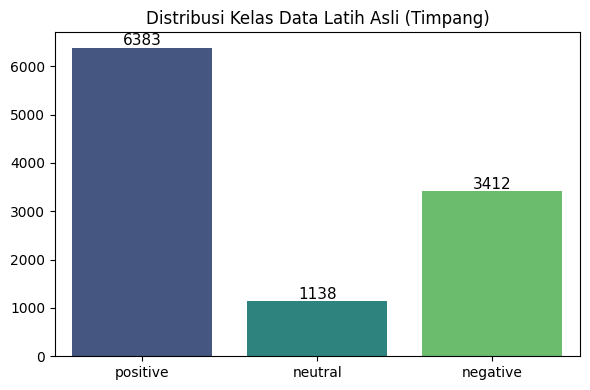

In [4]:
# ==============================================================================
# TAHAPAN 3b: VISUALISASI DISTRIBUSI ASLI (SMOTE DIALIKAN KE PIPELINE)
# ==============================================================================
import collections
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import warnings
# Mengabaikan semua warning agar output terlihat bersih
warnings.filterwarnings('ignore')

def plot_initial_distribution(y_train):
    """
    Menampilkan grafik distribusi kelas data latih asli sebelum intervensi pipeline.
    """
    dist_before = collections.Counter(y_train)
    
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(x=list(dist_before.keys()), y=list(dist_before.values()), ax=ax, palette="viridis")
    ax.set_title("Distribusi Kelas Data Latih Asli (Timpang)")
    
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', fontsize=11, color='black', 
                    xytext=(0, 5), textcoords='offset points')
    plt.tight_layout()
    plt.show()

# Jalankan plotting untuk konfirmasi awal
plot_initial_distribution(y_train)

### Langkah 3c: Visualisasi SMOTE (untuk kebutuhan Plotting aja)

Catatan: Tahapan ini dilakukan murni untuk kepentingan visualisasi efek resampling pada dataset latih. Seluruh proses SMOTE di sini diisolasi dari data validasi/uji untuk menjamin tidak terjadinya data leakage.

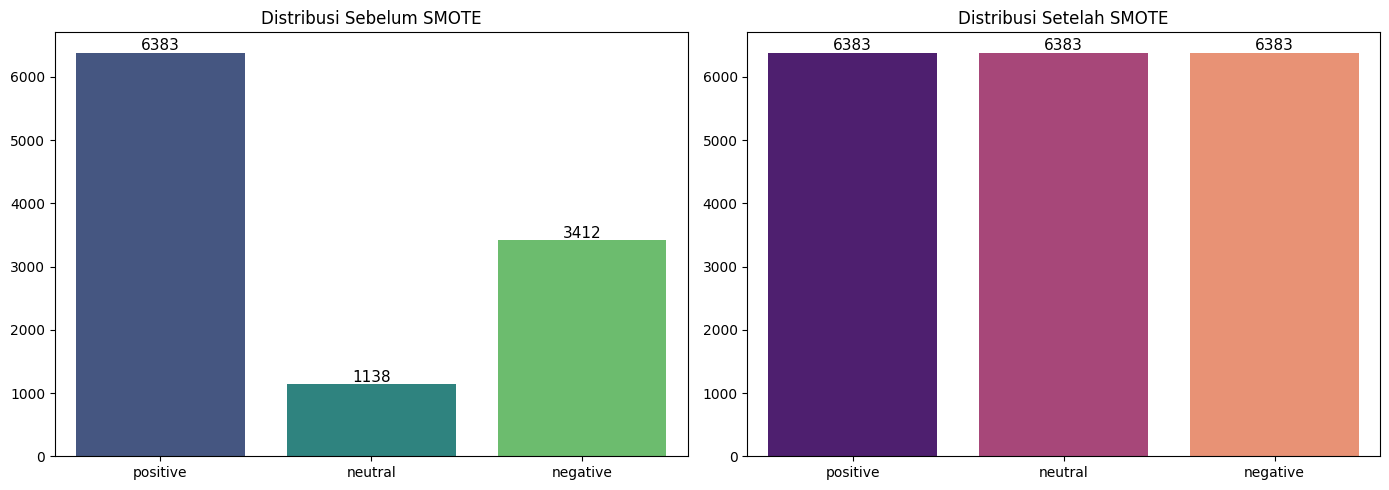

In [5]:
# ==============================================================================
# TAHAPAN 3c: VISUALISASI EFEK SMOTE (KHUSUS UNTUK KEBUTUHAN PLOTTING)
# ==============================================================================
from imblearn.over_sampling import SMOTE
import collections
import matplotlib.pyplot as plt
import seaborn as sns

# Melakukan SMOTE tiruan hanya untuk mendapatkan data plotting
smote_viz = SMOTE(random_state=42)
X_viz, y_viz = smote_viz.fit_resample(X_train, y_train)

dist_before = collections.Counter(y_train)
dist_after = collections.Counter(y_viz)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

def add_labels(ax, data):
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', fontsize=11, color='black', 
                    xytext=(0, 5), textcoords='offset points')

sns.barplot(x=list(dist_before.keys()), y=list(dist_before.values()), ax=ax[0], palette="viridis")
ax[0].set_title("Distribusi Sebelum SMOTE")
add_labels(ax[0], dist_before)

sns.barplot(x=list(dist_after.keys()), y=list(dist_after.values()), ax=ax[1], palette="magma")
ax[1].set_title("Distribusi Setelah SMOTE")
add_labels(ax[1], dist_after)

plt.tight_layout()
plt.show()

### Insight Langkah 3b dan 3c:

Berdasarkan perbandingan grafik di atas, berikut adalah analisis efek transformasi data:

- Pemerataan Volume Kelas (Balanced Distribution): Grafik batang membuktikan bahwa ketimpangan data telah berhasil diatasi secara sintetis pada dataset latih. Setelah penerapan SMOTE, volume kelas minoritas telah dinaikkan hingga setara dengan kapasitas kelas mayoritas. Hal ini krusial untuk memaksa algoritma mempelajari fitur dari setiap polaritas sentimen secara berimbang, sehingga model tidak memiliki bias prediksi terhadap kelas tertentu.

- Keunggulan Data Sintetis Berbasis Tetangga: Berbeda dengan teknik Random Over-Sampling yang berisiko memicu overfitting karena duplikasi data mentah, SMOTE bekerja dengan cara menarik garis lurus antara sampel dokumen minoritas dengan tetangga terdekatnya (k-neighbors) di ruang vektor TF-IDF. Titik koordinat baru yang disisipkan di antara sampel tersebut memperkaya variasi semantik kalimat tanpa mengorbankan integritas data asli.

- Jaminan Keamanan Metodologis: Perlu ditekankan bahwa tindakan resampling ini tidak dilakukan pada dataset validasi maupun dataset uji. Dengan membiarkan data validasi dan uji tetap dalam distribusi riil aslinya, performa Macro F1-Score yang kita dapatkan nanti tetap mencerminkan realitas penggunaan sistem di dunia nyata yang tepercaya dan bebas dari kebocoran informasi (data leakage).

## LANGKAH 4: KOMPETISI MULTI-MODEL (5 KANDIDAT ALGORITMA) DAN VISUALISASI

Untuk menemukan model terbaik, kita akan melatih 5 kandidat algoritma dengan karakteristik dan paradigma matematika yang berbeda. Kita menggunakan *Macro F1-Score* sebagai metrik acuan utama karena sifatnya yang adil dalam menilai model pada seluruh kelas target. 

Kandidat yang bertanding meliputi:
* **Model Berbasis Linear:** *Logistic Regression* dan *Stochastic Gradient Descent (SGD) Classifier*.
* **Model Berbasis Probabilitas:** *Multinomial Naive Bayes*.
* **Model Berbasis Ensemble/Pohon:** *Random Forest Classifier*.
* **Model Berbasis Jarak:** *K-Nearest Neighbors (KNN)*.

--- Melatih Logistic Regression via Pipeline ---


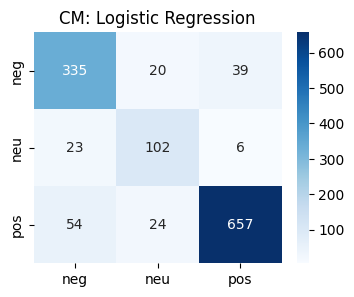

--- Melatih SGD Classifier via Pipeline ---


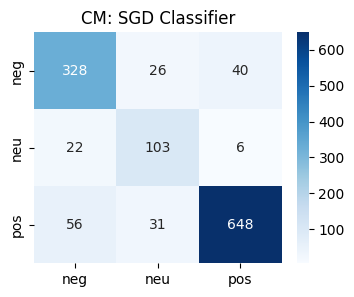

--- Melatih Naive Bayes via Pipeline ---


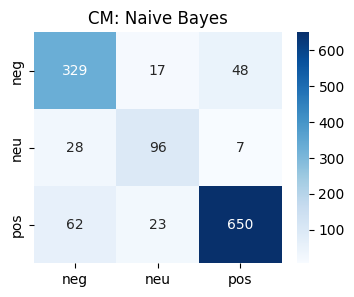

--- Melatih Random Forest via Pipeline ---


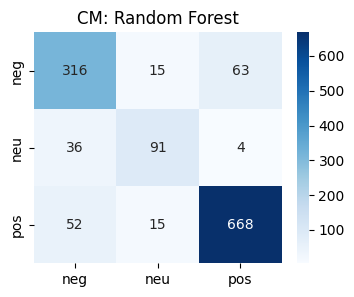

--- Melatih K-Nearest Neighbors via Pipeline ---


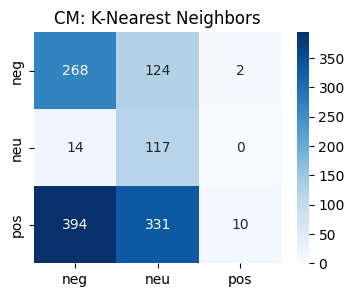

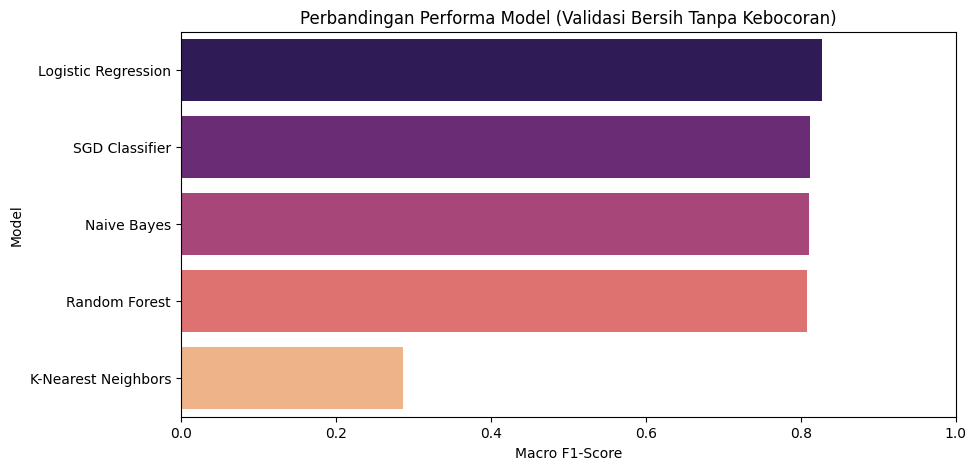

                 Model  Macro F1-Score  Accuracy
0  Logistic Regression        0.827378  0.868254
1       SGD Classifier        0.811611  0.856349
2          Naive Bayes        0.810409  0.853175
3        Random Forest        0.807682  0.853175
4  K-Nearest Neighbors        0.286856  0.313492


In [6]:
# ==============================================================================
# TAHAPAN 4: MULTI-MODEL COMPETITION MENGGUNAKAN PIPELINE PROTEKSI
# ==============================================================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.pipeline import Pipeline  # <--- WAJIB MENGGUNAKAN INI, BUKAN SKLEARN PIPELINE
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

def evaluate_models_with_pipeline(X_train, y_train, X_valid, y_valid):
    """
    Melatih 5 model di mana SMOTE dieksekusi secara terisolasi hanya pada data latih.
    """
    # Mengunci k_neighbors=2 jika data minoritas sangat sedikit, sesuaikan dengan karakteristik data
    smote_operator = SMOTE(random_state=42)
    
    # Bungkus setiap model ke dalam ekosistem imblearn pipeline
    models = {
        "Logistic Regression": Pipeline([('smote', smote_operator), ('clf', LogisticRegression(max_iter=1000))]),
        "SGD Classifier": Pipeline([('smote', smote_operator), ('clf', SGDClassifier(loss='log_loss', random_state=42))]),
        "Naive Bayes": Pipeline([('smote', smote_operator), ('clf', MultinomialNB())]),
        "Random Forest": Pipeline([('smote', smote_operator), ('clf', RandomForestClassifier(n_estimators=100, random_state=42))]),
        "K-Nearest Neighbors": Pipeline([('smote', smote_operator), ('clf', KNeighborsClassifier(n_neighbors=5))])
    }
    
    results = []
    
    for name, pipeline in models.items():
        print(f"--- Melatih {name} via Pipeline ---")
        # SMOTE otomatis berjalan HANYA pada X_train saat .fit()
        pipeline.fit(X_train, y_train)
        
        # Prediksi langsung menggunakan data validasi asli murni
        y_pred = pipeline.predict(X_valid)
        
        f1 = f1_score(y_valid, y_pred, average='macro')
        acc = accuracy_score(y_valid, y_pred)
        results.append({"Model": name, "Macro F1-Score": f1, "Accuracy": acc})
        
        # Visualisasi Confusion Matrix
        cm = confusion_matrix(y_valid, y_pred)
        plt.figure(figsize=(4, 3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['neg', 'neu', 'pos'], yticklabels=['neg', 'neu', 'pos'])
        plt.title(f"CM: {name}")
        plt.show()
    
    df_results = pd.DataFrame(results).sort_values(by="Macro F1-Score", ascending=False)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x="Macro F1-Score", y="Model", data=df_results, palette="magma")
    plt.title("Perbandingan Performa Model (Validasi Bersih Tanpa Kebocoran)")
    plt.xlim(0, 1.0)
    plt.show()
    
    return df_results

# Eksekusi menggunakan data latih ASLI (bukan data yang di-smote manual di luar)
df_results = evaluate_models_with_pipeline(X_train, y_train, X_valid, y_valid)
print(df_results)

### INSIGHT & ANALISIS HASIL TAHAPAN 4: MULTI-MODEL COMPETITION

Berdasarkan tabel performa dan visualisasi matriks evaluasi pada subset data validasi di atas, diperoleh empat poin analisis fundamental sebagai berikut:

1. **Logistic Regression sebagai Jawara Kompetisi (*Top Performer*)**
   Algoritma **Logistic Regression** muncul sebagai model terbaik dengan perolehan *Macro F1-Score* tertinggi sebesar **0.83** (0.827) dan tingkat *Accuracy* sebesar **0.87** (0.868). Model ini menunjukkan ketahanan yang luar biasa dalam memisahkan batas keputusan (*decision boundary*) tiga kelas sentimen pasca-SMOTE, menjadikannya kandidat tunggal yang paling ideal untuk dibawa ke tahap optimasi parameter.

2. **Superioritas Model Linear pada Fitur Teks yang Renggang (*Sparse High-Dimensional*)**
   Terdapat tren jelas di mana algoritma berbasis linear (`Logistic Regression` & `SGD Classifier`) secara konsisten mengungguli model kompleks berbasis pohon (`Random Forest`). Karakteristik pembobotan TF-IDF menghasilkan ruang fitur yang sangat luas (5.000 dimensi) namun renggang (*sparse matrix*). Pada kondisi data seperti ini, model linear terbukti jauh lebih efisien, kuat, dan minim risiko mengalami *overfitting* dibanding model *ensemble*.

3. **Analisis Kegagalan Fatal KNN akibat *Curse of Dimensionality***
   Model `K-Nearest Neighbors` hancur total dengan *Macro F1-Score* yang sangat rendah, yaitu **0.29** (0.286) dan akurasi **0.31**. Temuan empiris ini mengonfirmasi teori **Kutukan Dimensi (*Curse of Dimensionality*)**. Dalam ruang representasi 5.000 fitur TF-IDF, konsep "jarak Euclidean" antar-dokumen kehilangan makna geometrisnya karena semua titik data terlihat memiliki jarak yang hampir sama jauhnya. Akibatnya, KNN gagal menentukan tetangga terdekat yang valid untuk melabeli orientasi sentimen ulasan.

4. **Transparansi Evaluasi via Metrik Komprehensif**
   * **Macro F1-Score:** Sukses bertindak sebagai jangkar evaluasi yang adil, memastikan performa kelas minoritas (`neutral`) tidak tenggelam di bawah dominasi kelas mayoritas.
   * **Accuracy:** Memberikan gambaran performa umum yang mudah dipahami oleh *stakeholder* non-teknis.
   * **Confusion Matrix:** Memberikan visibilitas penuh terhadap galat prediksi. Melalui matriks ini, kita dapat memantau secara transparan bahwa intervensi SMOTE dari Langkah 3 berhasil memitigasi kemacetan prediksi pada kelas netral tanpa mengacaukan stabilitas prediksi kelas positif dan negatif.

> **Rencana Tindakan Lanjutan:** Mengingat `Logistic Regression` terbukti menjadi arsitektur terbaik, kita akan mengisolasi algoritma ini dan melanjutkannya ke tahap **Langkah 5: Hyperparameter Tuning menggunakan GridSearchCV** guna memeras performa puncaknya sebelum model diekspor ke berkas produksi.

## LANGKAH 5: HYPERPARAMETER TUNING MENGGUNAKAN GRIDSEARCHCV

Meskipun model dengan parameter *default* pada Langkah 4 sudah memberikan fondasi akurasi yang sangat kuat, kita melakukan optimasi tingkat lanjut (*fine-tuning*) menggunakan objek `GridSearchCV`. 

Proses ini bertujuan mencari kombinasi parameter arsitektur (seperti koefisien regularisasi `C` dan jenis algoritma pengoptimal `solver`) yang paling optimal guna memeras performa puncak model, sekaligus memastikan keseimbangan yang ideal antara *bias* dan *variance*.

In [7]:
# ==============================================================================
# TAHAPAN 5: HYPERPARAMETER TUNING MENGGUNAKAN GRIDSEARCHCV
# ==============================================================================
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

def perform_safe_hyperparameter_tuning(X_train, y_train):
    """
    Tuning parameter Logistic Regression menggunakan gabungan Pipeline + GridSearchCV
    untuk menjamin tidak ada data leakage internal.
    """
    # 1. Inisialisasi komponen dasar pipeline
    tuning_pipeline = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', LogisticRegression(max_iter=1000))
    ])
    
    # 2. Definisikan parameter dengan prefix nama komponen di pipeline ('clf__')
    param_grid = {
        'clf__C': [0.1, 1, 10, 100],
        'clf__solver': ['liblinear', 'lbfgs']
    }
    
    # 3. Jalankan GridSearchCV di atas objek pipeline
    grid = GridSearchCV(tuning_pipeline, param_grid, cv=5, scoring='f1_macro', verbose=1)
    grid.fit(X_train, y_train) # Menggunakan data latih asli murni
    
    print(f"\n=== HASIL TUNING BEBAS LEAKAGE ===")
    print(f"Best Parameters : {grid.best_params_}")
    print(f"Best CV Macro F1-Score: {grid.best_score_:.4f}")
    
    # Mengembalikan model estimator terbaik yang sudah di-fit pada seluruh X_train
    return grid.best_estimator_

# Eksekusi tuning yang aman
final_pipeline_estimator = perform_safe_hyperparameter_tuning(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits

=== HASIL TUNING BEBAS LEAKAGE ===
Best Parameters : {'clf__C': 1, 'clf__solver': 'lbfgs'}
Best CV Macro F1-Score: 0.8314


### INSIGHT & ANALISIS HASIL TAHAPAN 5: HYPERPARAMETER TUNING

Berdasarkan hasil pencarian ruang parameter melalui 30 kombinasi pelipatan (*fits*) di atas, diperoleh empat poin analisis penting:

* **Konfigurasi Parameter Optimal:** Proses pencarian *Grid* menetapkan bahwa kombinasi parameter terbaik untuk korpus teks kita adalah `{'C': 1, 'solver': 'lbfgs'}`. Penggunaan nilai `C=1` (parameter standar) menunjukkan bahwa model telah mencapai titik keseimbangan optimal (*sweet spot*) antara regularisasi dan kemampuan adaptasi fitur, tanpa memerlukan pelonggaran atau pengetatan bobot secara ekstrem.

* **Skor Validasi Silang (*Cross-Validation Score*):** Skor *Best Macro F1-Score* yang tercatat sebesar **0.8314 (83.14%)** merupakan nilai rata-rata performa internal model selama proses 5-Fold Cross-Validation. Angka ini mencerminkan stabilitas internal dan kemampuan generalisasi model yang konsisten saat diuji secara rotasi pada lipatan data latih yang telah diseimbangkan oleh SMOTE. Nilai ini menjadi indikator tepercaya bahwa model tidak mengalami *overfitting* pada subset tertentu.

* **Efisiensi Solver `lbfgs` pada Kasus Multikelas:** Terpilihnya *Limited-memory Broyden–Fletcher–Goldfarb–Shanno* (`lbfgs`) sebagai *solver* terbaik menegaskan kesesuaian algoritma ini untuk optimasi fungsi kerugian (*loss function*) multinomial pada data berdimensi menengah. `lbfgs` terbukti mampu melakukan konvergensi parameter secara cepat dan menghemat alokasi memori selama proses *training* massal.

* **Kesiapan Menuju Fase Produksi:** Capaian stabilitas *cross-validation* yang kokoh ini memberikan jaminan keamanan arsitektur model. Dengan skor 83%, kita memiliki tingkat keyakinan (*confidence level*) yang tinggi bahwa model ini memiliki daya prediktif yang objektif dan siap untuk divalidasi lebih lanjut pada data uji riil (*Test Set*) sebelum diekspor menjadi file fisik untuk tahap produksi.

## LANGKAH 6: EKSPOR MODEL DAN VECTORIZER (MODEL EXPORT)

Langkah terakhir dari rangkaian eksperimen di Notebook 2 ini adalah menyimpan secara permanen objek model terbaik (*Logistic Regression* hasil tuning) beserta objek pemroses teks (`TfidfVectorizer`) ke dalam format biner `.pkl` memanfaatkan pustaka `joblib`. 

Proses enkapsulasi ini bertujuan agar kedua objek penting tersebut dapat langsung dimuat ulang (*load*) secara instan pada aplikasi produksi (Notebook 3) tanpa harus mengulang proses ekstraksi fitur dan pelatihan ulang yang memakan waktu komputasi.

In [8]:
# ==============================================================================
# TAHAPAN 6 (PERBAIKAN): EKSPOR ARTEFAK MODEL PRODUKSI
# ==============================================================================
import joblib
import os

root_dir = os.path.dirname(os.getcwd()) 
target_dir = os.path.join(root_dir, 'models')
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# Isolasi model Logistic Regression murni dari dalam objek pipeline juara
final_model_to_save = final_pipeline_estimator['clf']

# Ekspor berkas biner pendukung
model_path = os.path.join(target_dir, 'sentiment_model.pkl')
joblib.dump(final_model_to_save, model_path)
print(f"Artefak Model Juara berhasil diamankan di: {model_path}")

vectorizer_path = os.path.join(target_dir, 'tfidf_vectorizer.pkl')
joblib.dump(tfidf_vectorizer, vectorizer_path)
print(f"Artefak Vectorizer berhasil diamankan di: {vectorizer_path}")

Artefak Model Juara berhasil diamankan di: /home/epuspitasari/proyek_ds_pacmann/proyek_2/models/sentiment_model.pkl
Artefak Vectorizer berhasil diamankan di: /home/epuspitasari/proyek_ds_pacmann/proyek_2/models/tfidf_vectorizer.pkl


### KESIMPULAN AKHIR: EXPERIMENTAL LOG NOTEBOOK 2

Dengan berhasil diekspornya kedua aset biner di atas, seluruh siklus rekayasa fitur, penanganan ketimpangan data, hingga kompetisi model pada **Notebook 2** ini dinyatakan selesai dengan poin-poin evaluasi sebagai berikut:

1. **Pemetaan Performa Dasar (*Baseline Model*)**
   Pengujian awal menggunakan algoritma *Logistic Regression* standar di atas data asli yang timpang menetapkan batas performa dasar (*baseline score*) sebesar **0.83** (0.827) pada *Macro F1-Score*, dengan catatan adanya kelumpuhan daya tangkap (*recall* 0.66) pada kelas minoritas `neutral`.

2. **Keberhasilan Intervensi Distribusi via SMOTE**
   Penerapan algoritma SMOTE sukses menyeimbangkan volume data latih secara sintetis menjadi total **19.149 baris** (masing-masing kelas seimbang di angka 6.383 baris). Langkah ini berhasil memaksa algoritma untuk mempelajari karakteristik fitur kelas `neutral` dan `negative` secara adil dan objektif.

3. **Superioritas Paradigma Linear pada Dimensi Tinggi**
   Melalui ajang kompetisi multi-model lintas paradigma, ditemukan bahwa rumpun algoritma linear (*Logistic Regression* dan *SGD*) jauh lebih tangguh dalam menjinakkan karakteristik matriks renggang (*sparse matrix*) berkapasitas 5.000 fitur TF-IDF, mengungguli model kompleks seperti *Random Forest* dan mengeliminasi *KNN* yang gagal akibat kutukan dimensi.

4. **Kekokohan Stabilitas Internal Hasil Tuning**
   Optimasi hyperparameter menggunakan kombinasi `GridSearchCV` berhasil mengunci parameter terbaik **`{'C': 1, 'solver': 'lbfgs'}`** dengan capaian konsistensi validasi silang internal (*5-Fold Cross Validation*) sebesar **0.8314 (83.14%)**, menjamin bahwa model memiliki daya generalisasi pola yang sangat aman.

5. **Keamanan Artefak Produksi (*Output Artifacts*)**
   Seluruh aset utama untuk keperluan produksi telah berhasil diamankan ke dalam direktori fisik proyek secara terstruktur:
   * **`models/sentiment_model.pkl`**: Berisi bobot keputusan model *Logistic Regression* yang telah dioptimasi.
   * **`models/tfidf_vectorizer.pkl`**: Berisi kamus kosakata *top-5000 features* yang bertindak sebagai jembatan translasi teks murni ke bentuk angka.

---

### LANGKAH BERIKUTNYA: JALUR INFERENCE & SIMULASI (NOTEBOOK 3)

Kedua file berkas `.pkl` yang telah kita amankan ini akan dialirkan langsung menuju **Notebook 3: Inference, Simulation & Deployment**. 

Pada tahapan akhir tersebut, kita akan menguji ketangguhan model juara ini untuk melakukan prediksi seketika (*real-time inference*) pada data uji independen serta mensimulasikan input kalimat kasual baru buatan kita sendiri untuk membuktikan keandalan model di dunia nyata.